In [49]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [50]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [51]:
# adjust paths if needed
features = pd.read_parquet("../../data/processed/market_all_features_with_sentiment.parquet")
features.head()

,date,open,high,low,close,volume,adj close,ticker,sector,cap,return,log_return,year,vol21,vol63,ret_ema21,ret_ema63,px_ma21,px_ma63,px_ma200,trend200_up,sent_mean,sent_std,sent_count,sent_pos,sent_neg,sent_neu,sent_daily_cat,sent_lag1,sent_cat_lag1,sent_roll3,row_id,is_train,set
0,2018-01-04,19.838642,19.958017,19.749111,19.935635,5738092.0,19.935635,ABB,Real Estate - Energy - Industrials,Mid Cap,0.010972,0.010913,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.000000,0.0,0.0,0.0,0.0,0.0,neutral,0.0,None,0.000000,ABB|2018-01-04,True,train
1,2018-01-04,7.882366,7.882366,7.882366,7.882366,0.0,7.882366,ALPINE,Consumer Discretionary,Large Cap,0.000000,0.000000,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.000000,0.0,0.0,0.0,0.0,0.0,neutral,0.0,None,0.000000,ALPINE|2018-01-04,True,train
2,2018-01-04,332.666046,333.091339,317.440460,323.224487,111998.0,323.224487,ARYZTA,Consumer Staples,Mid Cap,-0.024390,-0.024693,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.946913,0.0,1.0,1.0,0.0,0.0,positive,0.0,None,0.999941,ARYZTA|2018-01-04,True,train
3,2018-01-04,107.037628,107.741360,106.545007,107.670982,111416.0,107.670982,BALOISE,Insurance,Mid Cap,0.009235,0.009192,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.000000,0.0,0.0,0.0,0.0,0.0,neutral,0.0,None,0.000000,BALOISE|2018-01-04,True,train
4,2018-01-04,47.071196,47.562372,47.071196,47.480511,19374.0,47.480511,BKW ENERGIE,Real Estate - Energy - Industrials,Small Cap,0.003460,0.003454,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.041373,0.0,1.0,0.0,0.0,1.0,neutral,0.0,None,0.995683,BKW ENERGIE|2018-01-04,True,train


In [52]:
news_counts = features.groupby("ticker")["sent_count"].sum().sort_values(ascending=False)
news_counts


ticker
UBS                 30518.0
SWISSCOM             7052.0
NESTLE               5541.0
VONTOBEL             3208.0
BKW ENERGIE          3164.0
ABB                  3140.0
JULIUS BAER          2717.0
HELVETIA             2216.0
LONZA                2065.0
SWATCH               1952.0
SWISS LIFE           1928.0
SWISS RE             1761.0
HOLCIM               1630.0
ZURICH INSURANCE     1319.0
EMMI                 1297.0
RICHEMONT            1264.0
LOGITECH              969.0
BALOISE               895.0
SWISSQUOTE            887.0
ARYZTA                800.0
GIVAUDAN              770.0
LANDIS                770.0
BLKB                  526.0
SWISS PRIME SITE      438.0
ROCHE                 320.0
NOVARTIS              279.0
ALCON                 240.0
SANTHERA               97.0
ALPINE                 73.0
REISHAUER              67.0
Name: sent_count, dtype: float64

In [53]:
# If some entries are the string "None", turn them into real NaN first (just in case)
features["sent_cat_lag1"] = features["sent_cat_lag1"].replace("None", np.nan)

# 1) Category lag: treat missing as NEUTRAL
features["sent_cat_lag1"] = features["sent_cat_lag1"].fillna("neutral")

# 2) Numeric lag: treat missing as 0 (neutral score)
features["sent_lag1"] = features["sent_lag1"].fillna(0.0)

# 3) Rolling sentiment: also neutral when missing
features["sent_roll3"] = features["sent_roll3"].fillna(0.0)

# Quick check
print(features[["sent_daily_cat", "sent_lag1", "sent_cat_lag1", "sent_roll3"]].head())
print(features[["sent_cat_lag1"]].isna().sum())


  sent_daily_cat  sent_lag1 sent_cat_lag1  sent_roll3
0        neutral        0.0       neutral    0.000000
1        neutral        0.0       neutral    0.000000
2       positive        0.0       neutral    0.999941
3        neutral        0.0       neutral    0.000000
4        neutral        0.0       neutral    0.995683
sent_cat_lag1    0
dtype: int64


In [54]:
features.head()

,date,open,high,low,close,volume,adj close,ticker,sector,cap,return,log_return,year,vol21,vol63,ret_ema21,ret_ema63,px_ma21,px_ma63,px_ma200,trend200_up,sent_mean,sent_std,sent_count,sent_pos,sent_neg,sent_neu,sent_daily_cat,sent_lag1,sent_cat_lag1,sent_roll3,row_id,is_train,set
0,2018-01-04,19.838642,19.958017,19.749111,19.935635,5738092.0,19.935635,ABB,Real Estate - Energy - Industrials,Mid Cap,0.010972,0.010913,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.000000,0.0,0.0,0.0,0.0,0.0,neutral,0.0,neutral,0.000000,ABB|2018-01-04,True,train
1,2018-01-04,7.882366,7.882366,7.882366,7.882366,0.0,7.882366,ALPINE,Consumer Discretionary,Large Cap,0.000000,0.000000,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.000000,0.0,0.0,0.0,0.0,0.0,neutral,0.0,neutral,0.000000,ALPINE|2018-01-04,True,train
2,2018-01-04,332.666046,333.091339,317.440460,323.224487,111998.0,323.224487,ARYZTA,Consumer Staples,Mid Cap,-0.024390,-0.024693,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.946913,0.0,1.0,1.0,0.0,0.0,positive,0.0,neutral,0.999941,ARYZTA|2018-01-04,True,train
3,2018-01-04,107.037628,107.741360,106.545007,107.670982,111416.0,107.670982,BALOISE,Insurance,Mid Cap,0.009235,0.009192,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.000000,0.0,0.0,0.0,0.0,0.0,neutral,0.0,neutral,0.000000,BALOISE|2018-01-04,True,train
4,2018-01-04,47.071196,47.562372,47.071196,47.480511,19374.0,47.480511,BKW ENERGIE,Real Estate - Energy - Industrials,Small Cap,0.003460,0.003454,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.041373,0.0,1.0,0.0,0.0,1.0,neutral,0.0,neutral,0.995683,BKW ENERGIE|2018-01-04,True,train


## Create target and lag features

In [55]:
# === 1) Ensure correct ordering ===
# (date should already be datetime, but this is safe)
features["date"] = pd.to_datetime(features["date"], errors='coerce')

# Sort by ticker and date to make all shifts deterministic
features = features.sort_values(["ticker", "date"]).reset_index(drop=True)

# We'll work on a copy for modeling features
features_model = features.copy()

# === 2) Target: next-day return per ticker (t+1) ===
features_model["target_ret_next"] = features_model.groupby("ticker")["return"].shift(-1)

# === 3) Autoregressive lags of return (AR(5) style) ===
for lag in range(1, 6):
    features_model[f"ret_lag{lag}"] = features_model.groupby("ticker")["return"].shift(lag)

# === 4) Optional: lagged volatility (21-day) ===
features_model["vol21_lag1"] = features_model.groupby("ticker")["vol21"].shift(1)

# (⚠️ Do NOT drop NaNs yet; we will drop them
#  separately in train/test to keep the split consistent.)

print(features_model.shape)
features_model[[
    "date", "ticker",
    "return", "target_ret_next",
    "ret_lag1", "ret_lag2", "ret_lag3", "ret_lag4", "ret_lag5",
    "vol21", "vol21_lag1"
]].head(10)


(52424, 41)


,date,ticker,return,target_ret_next,ret_lag1,ret_lag2,ret_lag3,ret_lag4,ret_lag5,vol21,vol21_lag1
0,2018-01-04,ABB,0.010972,0.007485,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-01-05,ABB,0.007485,0.000372,0.010972,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-01-08,ABB,0.000372,0.005199,0.007485,0.010972,NaN,NaN,NaN,NaN,NaN
3,2018-01-09,ABB,0.005199,-0.007019,0.000372,0.007485,0.010972,NaN,NaN,NaN,NaN
4,2018-01-10,ABB,-0.007019,0.001116,0.005199,0.000372,0.007485,0.010972,NaN,NaN,NaN
5,2018-01-11,ABB,0.001116,0.008175,-0.007019,0.005199,0.000372,0.007485,0.010972,NaN,NaN
6,2018-01-12,ABB,0.008175,-0.007003,0.001116,-0.007019,0.005199,0.000372,0.007485,NaN,NaN
7,2018-01-15,ABB,-0.007003,0.005939,0.008175,0.001116,-0.007019,0.005199,0.000372,NaN,NaN
8,2018-01-16,ABB,0.005939,-0.012546,-0.007003,0.008175,0.001116,-0.007019,0.005199,NaN,NaN
9,2018-01-17,ABB,-0.012546,0.002242,0.005939,-0.007003,0.008175,0.001116,-0.007019,NaN,NaN


### Build train / test modeling DataFrames using existing split 

In [56]:
# Sanity: check that 'set' is still present
features_model[["set"]].value_counts()

set  
train    37394
test     15030
Name: count, dtype: int64

In [57]:
# 2.1 Create train/test based on fixed split
train_df = features_model[features_model["set"] == "train"].copy()
test_df  = features_model[features_model["set"] == "test"].copy()

In [58]:
train_df.ticker.value_counts()

ticker
ABB                 1257
ALPINE              1257
BALOISE             1257
ARYZTA              1257
BKW ENERGIE         1257
BLKB                1257
HOLCIM              1257
EMMI                1257
GIVAUDAN            1257
HELVETIA            1257
LANDIS              1257
JULIUS BAER         1257
LOGITECH            1257
LONZA               1257
SWISS LIFE          1257
NESTLE              1257
NOVARTIS            1257
REISHAUER           1257
RICHEMONT           1257
ROCHE               1257
SANTHERA            1257
SWATCH              1257
SWISSQUOTE          1257
SWISS PRIME SITE    1257
SWISS RE            1257
SWISSCOM            1257
VONTOBEL            1257
UBS                 1257
ZURICH INSURANCE    1257
ALCON                941
Name: count, dtype: int64

In [59]:
test_df.ticker.value_counts()

ticker
ABB                 501
ALCON               501
ALPINE              501
ARYZTA              501
BALOISE             501
BKW ENERGIE         501
BLKB                501
EMMI                501
GIVAUDAN            501
HELVETIA            501
HOLCIM              501
JULIUS BAER         501
LANDIS              501
LOGITECH            501
LONZA               501
NESTLE              501
NOVARTIS            501
REISHAUER           501
RICHEMONT           501
ROCHE               501
SANTHERA            501
SWATCH              501
SWISS LIFE          501
SWISS PRIME SITE    501
SWISS RE            501
SWISSCOM            501
SWISSQUOTE          501
UBS                 501
VONTOBEL            501
ZURICH INSURANCE    501
Name: count, dtype: int64

In [60]:
print("Raw shapes (before dropping NaNs):")
print("train_df:", train_df.shape)
print("test_df :", test_df.shape)

Raw shapes (before dropping NaNs):
train_df: (37394, 41)
test_df : (15030, 41)


In [61]:
# 2.2 For AR models, we at least need:
required_cols = ["target_ret_next"] + [f"ret_lag{i}" for i in range(1, 6)]
required_cols

['target_ret_next', 'ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag4', 'ret_lag5']

In [62]:
# Drop rows with missing target or AR lags *inside each set*
train_df = train_df.dropna(subset=required_cols).copy()
test_df  = test_df.dropna(subset=required_cols).copy()

In [63]:
print("\nAfter dropping rows with missing target/AR lags:")
print("train_df:", train_df.shape)
print("test_df :", test_df.shape)


After dropping rows with missing target/AR lags:
train_df: (37244, 41)
test_df : (15000, 41)


In [64]:
train_df.ticker.value_counts()

ticker
ABB                 1252
ALPINE              1252
BALOISE             1252
ARYZTA              1252
BKW ENERGIE         1252
BLKB                1252
HOLCIM              1252
EMMI                1252
GIVAUDAN            1252
HELVETIA            1252
LANDIS              1252
JULIUS BAER         1252
LOGITECH            1252
LONZA               1252
SWISS LIFE          1252
NESTLE              1252
NOVARTIS            1252
REISHAUER           1252
RICHEMONT           1252
ROCHE               1252
SANTHERA            1252
SWATCH              1252
SWISSQUOTE          1252
SWISS PRIME SITE    1252
SWISS RE            1252
SWISSCOM            1252
VONTOBEL            1252
UBS                 1252
ZURICH INSURANCE    1252
ALCON                936
Name: count, dtype: int64

In [65]:
test_df.ticker.value_counts()

ticker
ABB                 500
ALCON               500
ALPINE              500
ARYZTA              500
BALOISE             500
BKW ENERGIE         500
BLKB                500
EMMI                500
GIVAUDAN            500
HELVETIA            500
HOLCIM              500
JULIUS BAER         500
LANDIS              500
LOGITECH            500
LONZA               500
NESTLE              500
NOVARTIS            500
REISHAUER           500
RICHEMONT           500
ROCHE               500
SANTHERA            500
SWATCH              500
SWISS LIFE          500
SWISS PRIME SITE    500
SWISS RE            500
SWISSCOM            500
SWISSQUOTE          500
UBS                 500
VONTOBEL            500
ZURICH INSURANCE    500
Name: count, dtype: int64

In [66]:
# Quick preview
train_df[[
    "date", "ticker",
    "return", "target_ret_next",
    "ret_lag1", "ret_lag2", "ret_lag3", "ret_lag4", "ret_lag5"
]].head()

,date,ticker,return,target_ret_next,ret_lag1,ret_lag2,ret_lag3,ret_lag4,ret_lag5
5,2018-01-11,ABB,0.001116,0.008175,-0.007019,0.005199,0.000372,0.007485,0.010972
6,2018-01-12,ABB,0.008175,-0.007003,0.001116,-0.007019,0.005199,0.000372,0.007485
7,2018-01-15,ABB,-0.007003,0.005939,0.008175,0.001116,-0.007019,0.005199,0.000372
8,2018-01-16,ABB,0.005939,-0.012546,-0.007003,0.008175,0.001116,-0.007019,0.005199
9,2018-01-17,ABB,-0.012546,0.002242,0.005939,-0.007003,0.008175,0.001116,-0.007019


## Baseline AR

### Baseline (market-only) feature set

In [67]:
baseline_features = [
    # AR lags
    "ret_lag1", "ret_lag2", "ret_lag3", "ret_lag4", "ret_lag5",
    
    # volatility features
    "vol21", "vol63", "vol21_lag1",
    
    # trend features
    "ret_ema21", "ret_ema63",
    "px_ma21", "px_ma63", "px_ma200",
    "trend200_up",
]


### Prepare X_train_base, X_test_base

In [68]:
# Drop NaN rows ONLY inside the split
train_base = train_df.dropna(subset=baseline_features + ["target_ret_next"]).copy()
test_base  = test_df.dropna(subset=baseline_features + ["target_ret_next"]).copy()

X_train_base = train_base[baseline_features]
y_train_base = train_base["target_ret_next"]

X_test_base = test_base[baseline_features]
y_test_base = test_base["target_ret_next"]

X_train_base.shape, X_test_base.shape


((35504, 14), (15000, 14))

### Scale baseline features (train-only fit)

In [69]:
from sklearn.preprocessing import StandardScaler

# Columns that will be scaled
scale_cols_base = baseline_features  # all numeric in baseline

# Initialize scaler
scaler_base = StandardScaler()

# Fit scaler ONLY on the training data
scaler_base.fit(X_train_base[scale_cols_base])

# Transform both train and test
X_train_base_scaled = X_train_base.copy()
X_test_base_scaled = X_test_base.copy()

X_train_base_scaled[scale_cols_base] = scaler_base.transform(X_train_base[scale_cols_base])
X_test_base_scaled[scale_cols_base] = scaler_base.transform(X_test_base[scale_cols_base])

X_train_base_scaled.head()


,ret_lag1,ret_lag2,ret_lag3,ret_lag4,ret_lag5,vol21,vol63,vol21_lag1,ret_ema21,ret_ema63,px_ma21,px_ma63,px_ma200,trend200_up
63,-0.849978,-1.044460,0.504263,0.158136,1.187177,-0.242760,-0.191284,-0.210264,-0.807297,-0.565310,-0.434325,-0.432455,-0.434121,-1.183925
64,1.717769,-0.849494,-1.044664,0.504117,0.158081,-0.094006,-0.130554,-0.242980,-0.042593,-0.121929,-0.434327,-0.432541,-0.434157,-1.183925
65,-0.685954,1.719116,-0.849707,-1.044606,0.504075,-0.074545,-0.129667,-0.093939,-0.314047,-0.287684,-0.434357,-0.432639,-0.434198,-1.183925
66,0.504411,-0.685415,1.718779,-0.849675,-1.044709,-0.058251,-0.121764,-0.074441,-0.082127,-0.153467,-0.434368,-0.432732,-0.434233,-1.183925
67,0.566096,0.505350,-0.685636,1.718473,-0.849771,-0.064040,-0.114811,-0.058115,0.153516,-0.008167,-0.434382,-0.432822,-0.434262,-1.183925


### Fit Linear Regression Baseline Model

In [70]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Initialize linear regression
lin_base = LinearRegression()

# Fit on training data
lin_base.fit(X_train_base_scaled, y_train_base)

# Predict on test
y_pred_base = lin_base.predict(X_test_base_scaled)


### Evaluate Baseline Model

In [71]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def directional_accuracy(y_true, y_pred):
    return np.mean(np.sign(y_true) == np.sign(y_pred))

# ==== Compute metrics ====

# MSE and RMSE
mse_base  = mean_squared_error(y_test_base, y_pred_base)
rmse_base = np.sqrt(mse_base)

# MAE
mae_base = mean_absolute_error(y_test_base, y_pred_base)

# R²
r2_base = r2_score(y_test_base, y_pred_base)

# Directional Accuracy
dir_acc_base = directional_accuracy(y_test_base, y_pred_base)

# ==== Print results ====
print("=== Baseline Linear AR (Market-only) ===")
print(f"MSE : {mse_base:.6f}")
print(f"RMSE: {rmse_base:.6f}")
print(f"MAE : {mae_base:.6f}")
print(f"R²  : {r2_base:.4f}")
print(f"Directional accuracy: {dir_acc_base:.4f}")



=== Baseline Linear AR (Market-only) ===
MSE : 0.000242
RMSE: 0.015566
MAE : 0.009997
R²  : -0.0023
Directional accuracy: 0.4928


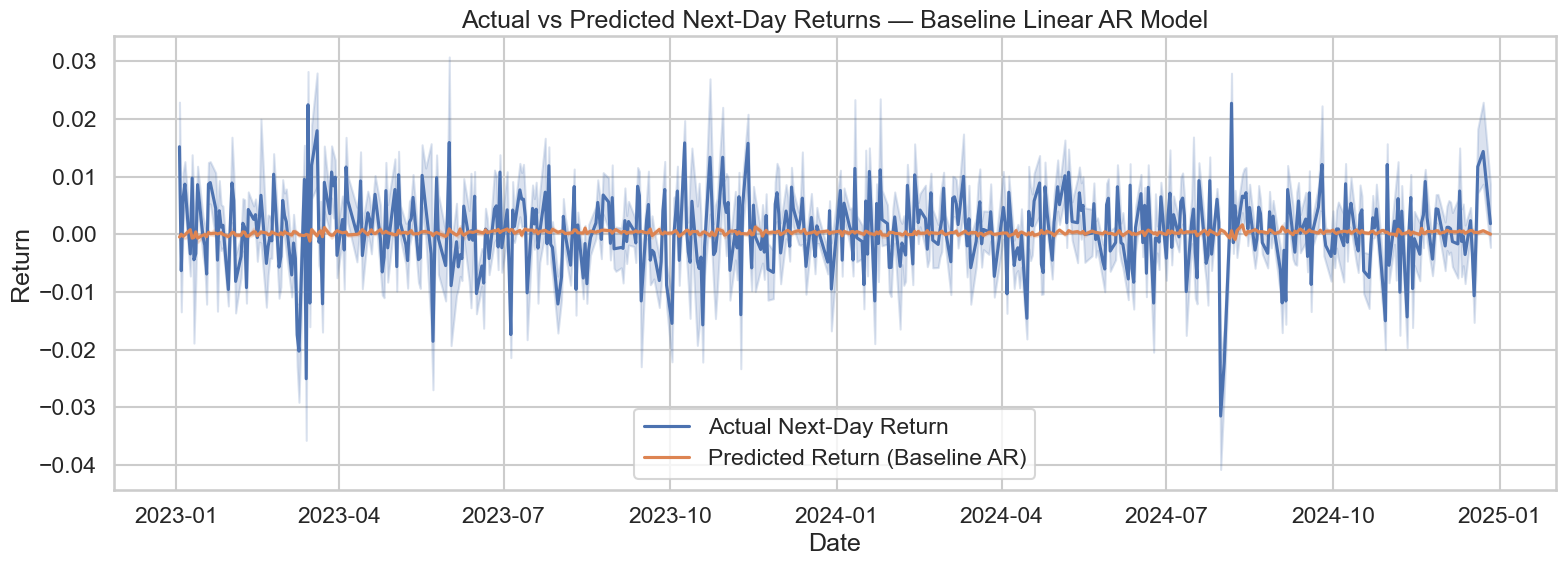

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = test_base.copy()
plot_df["pred_base"] = y_pred_base
plot_df = plot_df.sort_values("date")

sns.set(style="whitegrid", context="talk")

plt.figure(figsize=(16,6))
sns.lineplot(x="date", y="target_ret_next", data=plot_df, label="Actual Next-Day Return")
sns.lineplot(x="date", y="pred_base", data=plot_df, label="Predicted Return (Baseline AR)")
plt.title("Actual vs Predicted Next-Day Returns — Baseline Linear AR Model")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.tight_layout()
plt.show()


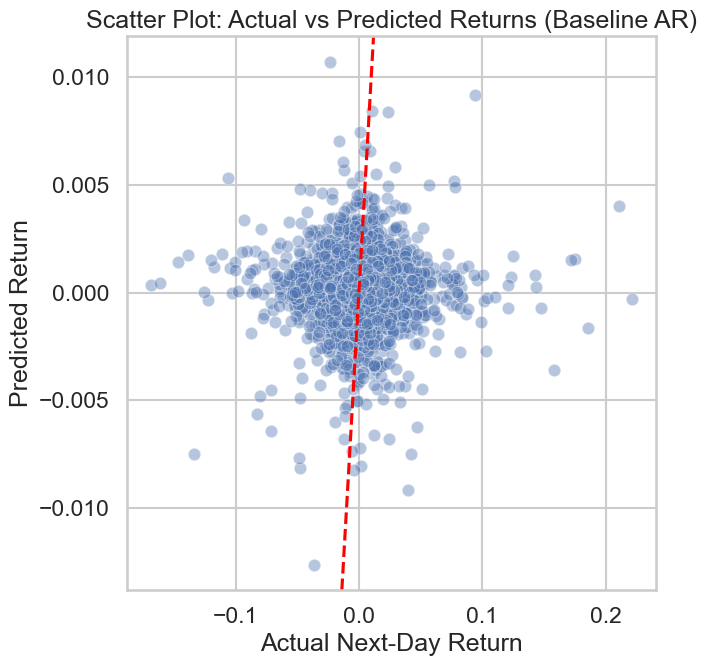

In [73]:
plt.figure(figsize=(7,7))
sns.scatterplot(x=plot_df["target_ret_next"], y=plot_df["pred_base"], alpha=0.4)
plt.axline((0,0), slope=1, color="red", linestyle="--")
plt.title("Scatter Plot: Actual vs Predicted Returns (Baseline AR)")
plt.xlabel("Actual Next-Day Return")
plt.ylabel("Predicted Return")
plt.tight_layout()
plt.show()


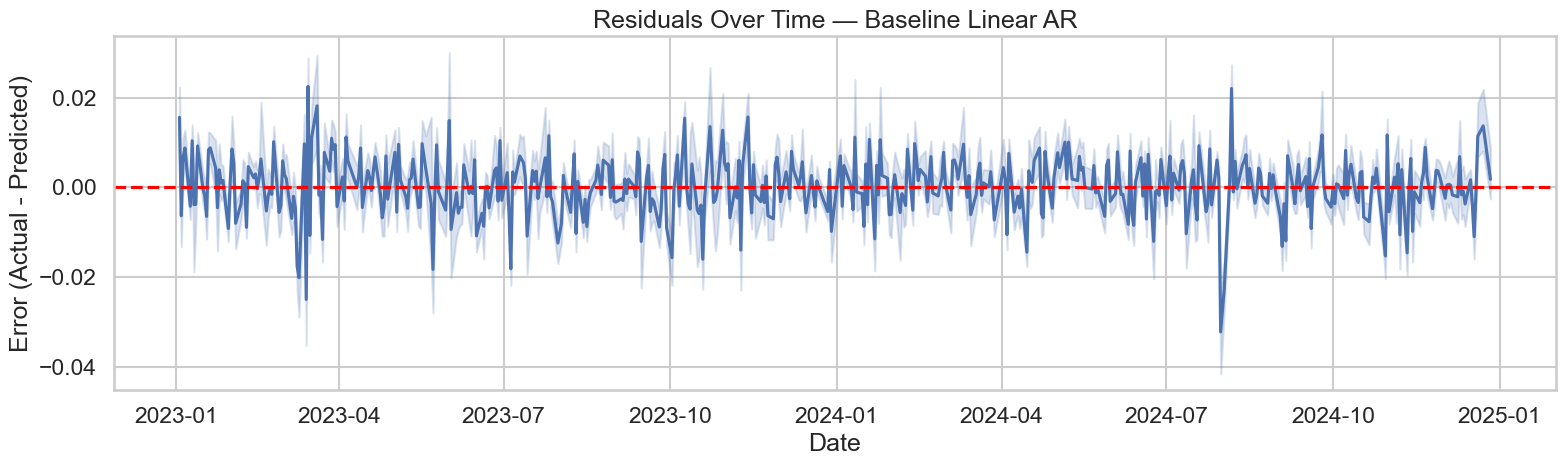

In [74]:
plot_df["residual"] = plot_df["target_ret_next"] - plot_df["pred_base"]

plt.figure(figsize=(16,5))
sns.lineplot(x="date", y="residual", data=plot_df)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals Over Time — Baseline Linear AR")
plt.xlabel("Date")
plt.ylabel("Error (Actual - Predicted)")
plt.tight_layout()
plt.show()


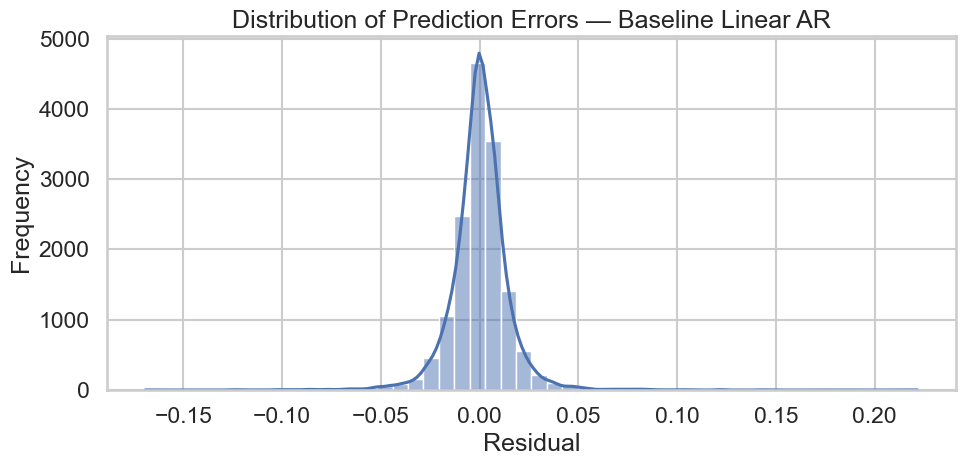

In [75]:
plt.figure(figsize=(10,5))
sns.histplot(plot_df["residual"], kde=True, bins=50)
plt.title("Distribution of Prediction Errors — Baseline Linear AR")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


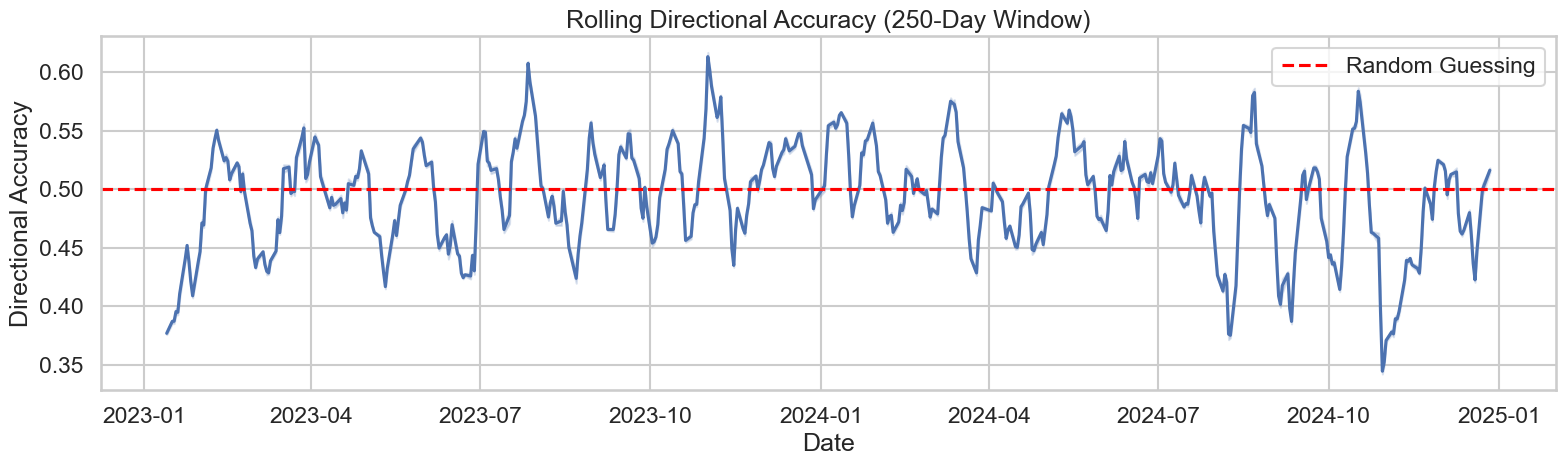

In [76]:
import numpy as np

plot_df["correct_dir"] = (
    np.sign(plot_df["target_ret_next"]) == np.sign(plot_df["pred_base"])
).astype(int)

plot_df["rolling_dir_acc"] = (
    plot_df["correct_dir"].rolling(250).mean()
)

plt.figure(figsize=(16,5))
sns.lineplot(x="date", y="rolling_dir_acc", data=plot_df)
plt.title("Rolling Directional Accuracy (250-Day Window)")
plt.xlabel("Date")
plt.ylabel("Directional Accuracy")
plt.axhline(0.5, color="red", linestyle="--", label="Random Guessing")
plt.legend()
plt.tight_layout()
plt.show()


In [77]:
prediction_sample = plot_df[[
    "date", "ticker", "target_ret_next", "pred_base", "residual"
]].head(20)

prediction_sample


,date,ticker,target_ret_next,pred_base,residual
1257,2023-01-03,ABB,0.033751,-0.000233,0.033983
46649,2023-01-03,SWISSQUOTE,0.011774,-0.001045,0.012819
44891,2023-01-03,SWISSCOM,0.010861,-0.000730,0.011591
43133,2023-01-03,SWISS RE,0.045769,-0.000713,0.046482
41375,2023-01-03,SWISS PRIME SITE,0.020669,-0.000268,0.020937
39617,2023-01-03,SWISS LIFE,0.016803,-0.000644,0.017448
37859,2023-01-03,SWATCH,0.019834,0.000515,0.019319
36101,2023-01-03,SANTHERA,-0.070968,-0.006405,-0.064563
34343,2023-01-03,ROCHE,0.013615,0.000162,0.013453
32585,2023-01-03,RICHEMONT,0.023959,0.001258,0.022701


## Multimodal Linear AR + Sentiment Model

### Define multimodal feature set including sentiment

In [78]:
# Numeric mapping of categorical t-1 sentiment
sent_map = {"negative": -1, "neutral": 0, "positive": 1}
train_df["sent_cat_lag1_num"] = train_df["sent_cat_lag1"].map(sent_map)
test_df["sent_cat_lag1_num"] = test_df["sent_cat_lag1"].map(sent_map)

multimodal_features = baseline_features + [
    "sent_lag1",          # numeric t-1 sentiment
    "sent_cat_lag1_num",  # categorical t-1 sentiment mapped
    "sent_roll3"          # past sentiment trend
]

multimodal_features 

['ret_lag1',
 'ret_lag2',
 'ret_lag3',
 'ret_lag4',
 'ret_lag5',
 'vol21',
 'vol63',
 'vol21_lag1',
 'ret_ema21',
 'ret_ema63',
 'px_ma21',
 'px_ma63',
 'px_ma200',
 'trend200_up',
 'sent_lag1',
 'sent_cat_lag1_num',
 'sent_roll3']

### Drop NaNs only inside train/test

In [79]:
train_mm = train_df.dropna(subset=multimodal_features + ["target_ret_next"]).copy()
test_mm  = test_df.dropna(subset=multimodal_features + ["target_ret_next"]).copy()

X_train_mm = train_mm[multimodal_features]
y_train_mm = train_mm["target_ret_next"]

X_test_mm = test_mm[multimodal_features]
y_test_mm = test_mm["target_ret_next"]


### Scale multimodal features (train-only)

In [80]:
from sklearn.preprocessing import StandardScaler

scale_cols_mm = multimodal_features  # all numeric

scaler_mm = StandardScaler()
scaler_mm.fit(X_train_mm[scale_cols_mm])

X_train_mm_scaled = X_train_mm.copy()
X_test_mm_scaled = X_test_mm.copy()

X_train_mm_scaled[scale_cols_mm] = scaler_mm.transform(X_train_mm[scale_cols_mm])
X_test_mm_scaled[scale_cols_mm] = scaler_mm.transform(X_test_mm[scale_cols_mm])


### Fit multimodal linear model

In [81]:
lin_mm = LinearRegression()
lin_mm.fit(X_train_mm_scaled, y_train_mm)

y_pred_mm = lin_mm.predict(X_test_mm_scaled)


### Evaluate multimodal model

In [82]:
mse_mm  = mean_squared_error(y_test_mm, y_pred_mm)
rmse_mm = np.sqrt(mse_mm)
mae_mm = mean_absolute_error(y_test_mm, y_pred_mm)
r2_mm = r2_score(y_test_mm, y_pred_mm)
dir_acc_mm = directional_accuracy(y_test_mm, y_pred_mm)

print("=== Linear AR + Sentiment (Multimodal) ===")
print(f"MSE : {mse_mm:.6f}")
print(f"RMSE: {rmse_mm:.6f}")
print(f"MAE : {mae_mm:.6f}")
print(f"R²  : {r2_mm:.4f}")
print(f"Directional accuracy: {dir_acc_mm:.4f}")



=== Linear AR + Sentiment (Multimodal) ===
MSE : 0.000242
RMSE: 0.015566
MAE : 0.009997
R²  : -0.0024
Directional accuracy: 0.4930


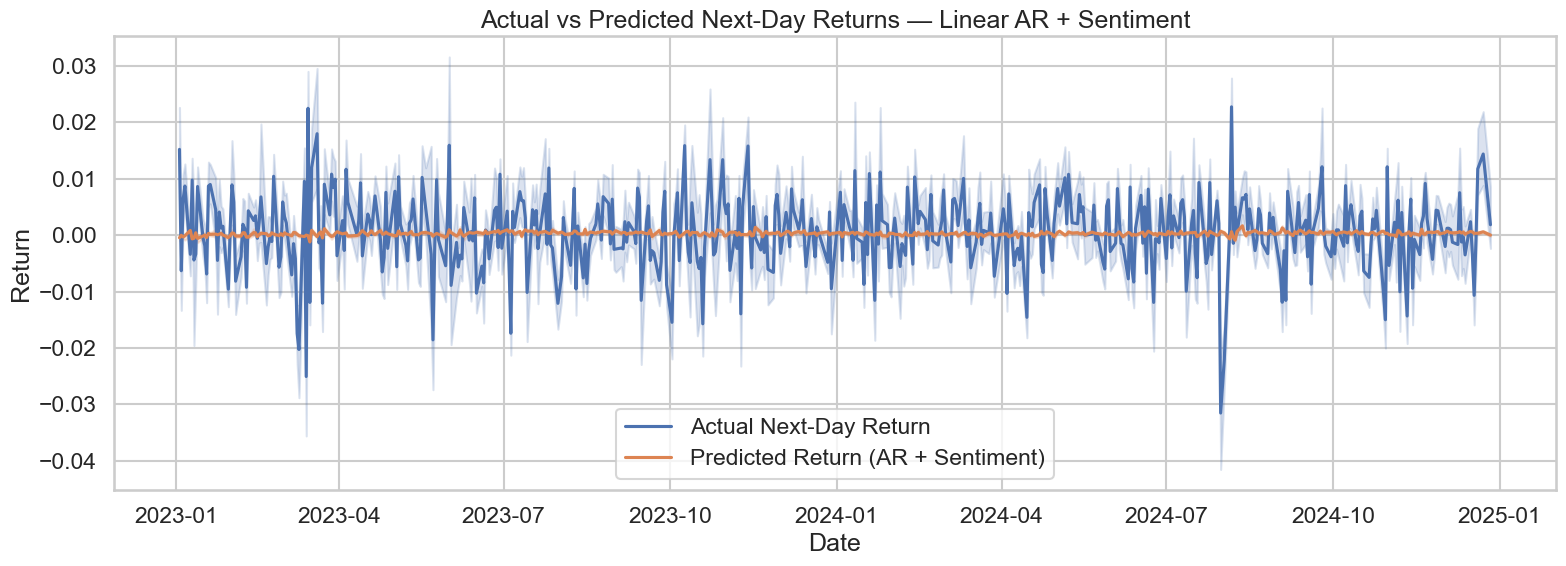

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_mm = test_mm.copy()
plot_mm["pred_mm"] = y_pred_mm
plot_mm = plot_mm.sort_values("date")

sns.set(style="whitegrid", context="talk")

plt.figure(figsize=(16,6))
sns.lineplot(x="date", y="target_ret_next", data=plot_mm, label="Actual Next-Day Return")
sns.lineplot(x="date", y="pred_mm", data=plot_mm, label="Predicted Return (AR + Sentiment)")
plt.title("Actual vs Predicted Next-Day Returns — Linear AR + Sentiment")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.tight_layout()
plt.show()


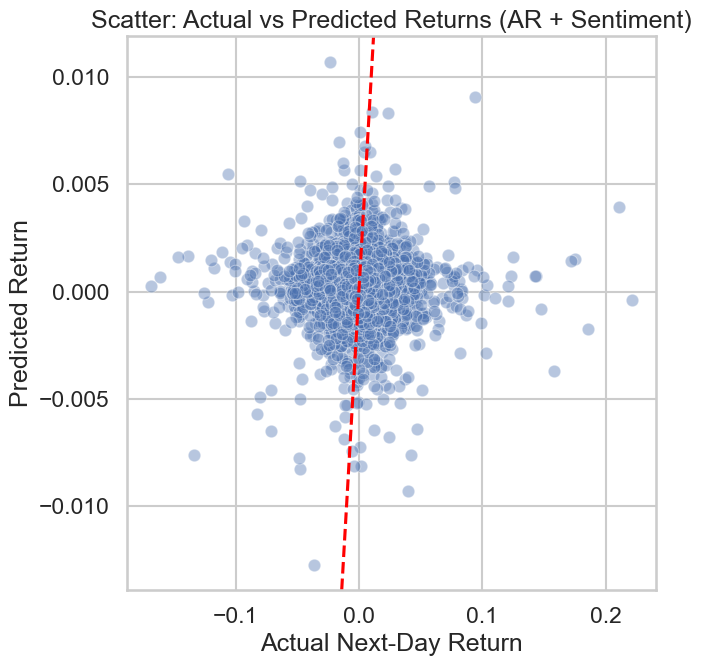

In [84]:
plt.figure(figsize=(7,7))
sns.scatterplot(x=plot_mm["target_ret_next"], y=plot_mm["pred_mm"], alpha=0.4)
plt.axline((0,0), slope=1, color="red", linestyle="--")
plt.title("Scatter: Actual vs Predicted Returns (AR + Sentiment)")
plt.xlabel("Actual Next-Day Return")
plt.ylabel("Predicted Return")
plt.tight_layout()
plt.show()


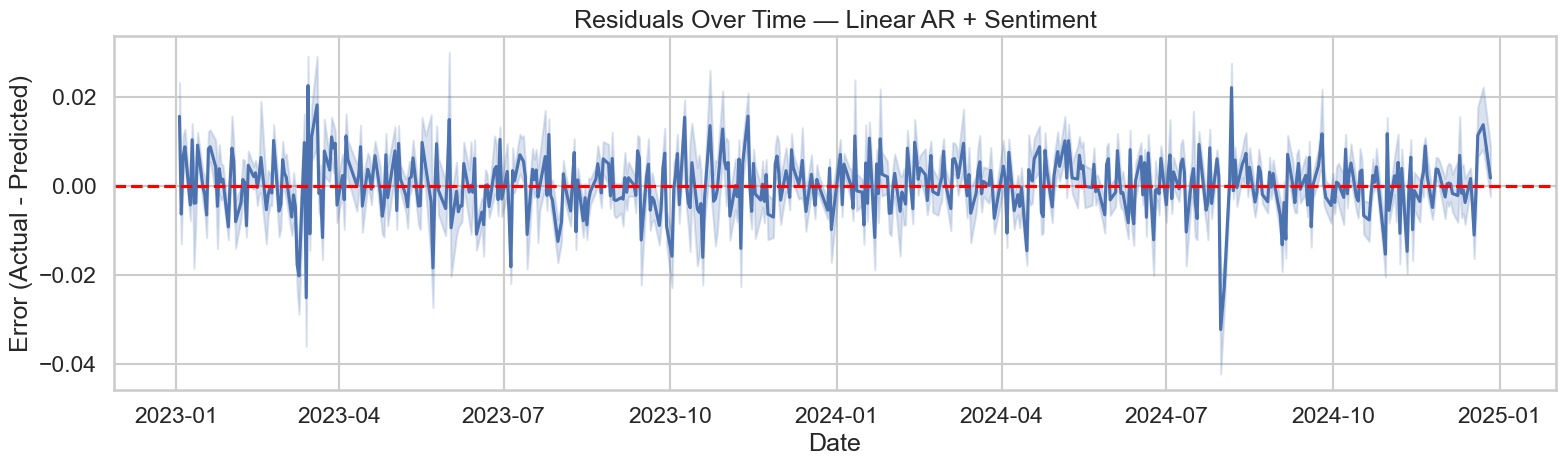

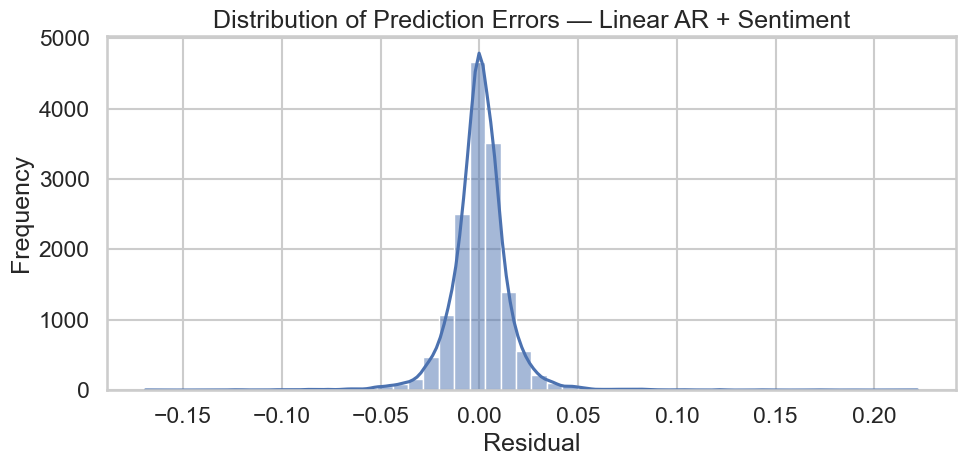

In [85]:
plot_mm["residual_mm"] = plot_mm["target_ret_next"] - plot_mm["pred_mm"]

# Residuals over time
plt.figure(figsize=(16,5))
sns.lineplot(x="date", y="residual_mm", data=plot_mm)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals Over Time — Linear AR + Sentiment")
plt.xlabel("Date")
plt.ylabel("Error (Actual - Predicted)")
plt.tight_layout()
plt.show()

# Error distribution
plt.figure(figsize=(10,5))
sns.histplot(plot_mm["residual_mm"], kde=True, bins=50)
plt.title("Distribution of Prediction Errors — Linear AR + Sentiment")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


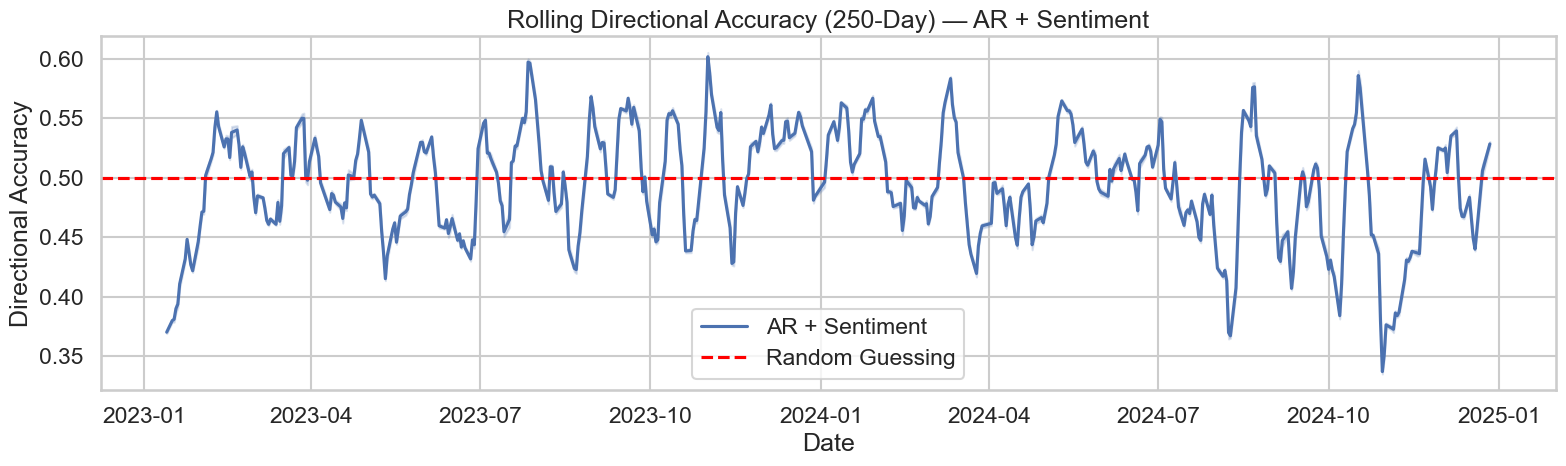

In [86]:
import numpy as np

plot_mm["correct_dir_mm"] = (
    np.sign(plot_mm["target_ret_next"]) == np.sign(plot_mm["pred_mm"])
).astype(int)

plot_mm["rolling_dir_acc_mm"] = plot_mm["correct_dir_mm"].rolling(250).mean()

plt.figure(figsize=(16,5))
sns.lineplot(x="date", y="rolling_dir_acc_mm", data=plot_mm, label="AR + Sentiment")
plt.axhline(0.5, color="red", linestyle="--", label="Random Guessing")
plt.title("Rolling Directional Accuracy (250-Day) — AR + Sentiment")
plt.xlabel("Date")
plt.ylabel("Directional Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


In [87]:
prediction_sample_mm = plot_mm[[
    "date",
    "ticker",
    "target_ret_next",
    "pred_mm",
    "residual_mm"
]].head(20)

prediction_sample_mm


,date,ticker,target_ret_next,pred_mm,residual_mm
1257,2023-01-03,ABB,0.033751,-0.000351,0.034102
46649,2023-01-03,SWISSQUOTE,0.011774,-0.001153,0.012927
44891,2023-01-03,SWISSCOM,0.010861,-0.000286,0.011147
43133,2023-01-03,SWISS RE,0.045769,-0.000525,0.046295
41375,2023-01-03,SWISS PRIME SITE,0.020669,-0.000387,0.021055
39617,2023-01-03,SWISS LIFE,0.016803,-0.000275,0.017079
37859,2023-01-03,SWATCH,0.019834,0.000402,0.019432
36101,2023-01-03,SANTHERA,-0.070968,-0.006492,-0.064475
34343,2023-01-03,ROCHE,0.013615,0.000051,0.013564
32585,2023-01-03,RICHEMONT,0.023959,0.001149,0.022810


## Analysis

### Per-company model performance

In [88]:
# Create dataframe with true and predicted values for BOTH models
cmp = test_base[["row_id", "date", "ticker", "target_ret_next"]].copy()
cmp["pred_base"] = y_pred_base

tmp_mm = test_mm[["row_id"]].copy()
tmp_mm["pred_mm"] = y_pred_mm

cmp = cmp.merge(tmp_mm, on="row_id", how="inner")

# Compute direction accuracy per company for ALL companies, and show the full table (not just first 3)
from sklearn.metrics import mean_squared_error

company_metrics = (
    cmp.groupby("ticker")
       .apply(lambda df: pd.Series({
           "RMSE_base":  np.sqrt(mean_squared_error(df["target_ret_next"], df["pred_base"])),
           "RMSE_mm":    np.sqrt(mean_squared_error(df["target_ret_next"], df["pred_mm"])),
           "DirAcc_base": np.mean(np.sign(df["target_ret_next"]) == np.sign(df["pred_base"])),
           "DirAcc_mm":   np.mean(np.sign(df["target_ret_next"]) == np.sign(df["pred_mm"])),
       }))
       .reset_index()
)

# Display the entire company_metrics table sorted by DirAcc_mm descending
display(company_metrics.sort_values("DirAcc_mm", ascending=False).reset_index(drop=True))


C:\Users\mkcak\AppData\Local\Temp\ipykernel_4992\1212261374.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: pd.Series({


,ticker,RMSE_base,RMSE_mm,DirAcc_base,DirAcc_mm
0,UBS,0.017522,0.017511,0.540,0.560
1,LONZA,0.020645,0.020654,0.532,0.536
2,LOGITECH,0.019833,0.019843,0.546,0.532
3,ZURICH INSURANCE,0.009091,0.009089,0.522,0.528
4,ABB,0.013751,0.013746,0.496,0.528
5,HELVETIA,0.011474,0.011471,0.532,0.522
6,NOVARTIS,0.010921,0.010930,0.516,0.518
7,RICHEMONT,0.018140,0.018136,0.526,0.518
8,SWISS RE,0.013089,0.013092,0.528,0.518
9,ROCHE,0.011171,0.011170,0.528,0.518


### CAP-LEVEL Performance (Small / Mid / Large Cap)

In [89]:
# Attach cap info to cmp
cmp_cap = cmp.merge(features_model[["row_id", "cap"]], on="row_id", how="left")

cap_metrics = (
    cmp_cap.groupby("cap")
           .apply(lambda df: pd.Series({
               "RMSE_base":  np.sqrt(mean_squared_error(df["target_ret_next"], df["pred_base"])),
               "RMSE_mm":    np.sqrt(mean_squared_error(df["target_ret_next"], df["pred_mm"])),
               "DirAcc_base": np.mean(np.sign(df["target_ret_next"]) == np.sign(df["pred_base"])),
               "DirAcc_mm":   np.mean(np.sign(df["target_ret_next"]) == np.sign(df["pred_mm"])),
           }))
           .reset_index()
)

cap_metrics


C:\Users\mkcak\AppData\Local\Temp\ipykernel_4992\2490693808.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: pd.Series({


,cap,RMSE_base,RMSE_mm,DirAcc_base,DirAcc_mm
0,Large Cap,0.013404,0.013405,0.446333,0.4390
1,Mid Cap,0.017676,0.017679,0.504667,0.5045
2,Small Cap,0.014264,0.014262,0.504167,0.5085


### SECTOR-LEVEL Performance

In [90]:
# Attach sector info to cmp
cmp_sector = cmp.merge(features_model[["row_id", "sector"]], on="row_id", how="left")

sector_metrics = (
    cmp_sector.groupby("sector")
              .apply(lambda df: pd.Series({
                  "RMSE_base":  np.sqrt(mean_squared_error(df["target_ret_next"], df["pred_base"])),
                  "RMSE_mm":    np.sqrt(mean_squared_error(df["target_ret_next"], df["pred_mm"])),
                  "DirAcc_base": np.mean(np.sign(df["target_ret_next"]) == np.sign(df["pred_base"])),
                  "DirAcc_mm":   np.mean(np.sign(df["target_ret_next"]) == np.sign(df["pred_mm"])),
              }))
              .reset_index()
)

sector_metrics.sort_values("DirAcc_mm", ascending=False)


C:\Users\mkcak\AppData\Local\Temp\ipykernel_4992\1829873319.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: pd.Series({


,sector,RMSE_base,RMSE_mm,DirAcc_base,DirAcc_mm
7,Technology,0.015201,0.015207,0.514000,0.518000
5,Materials,0.012171,0.012168,0.519000,0.512000
3,Health Care,0.021965,0.021969,0.514000,0.511600
4,Insurance,0.011230,0.011231,0.508800,0.505600
6,Real Estate - Energy - Industrials,0.014087,0.014080,0.482800,0.494800
0,Banking,0.015020,0.015016,0.488000,0.490000
2,Consumer Staples,0.012940,0.012951,0.488667,0.483333
1,Consumer Discretionary,0.016785,0.016783,0.428000,0.423333
